In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("diabetes_data/diabetic_data.csv")

In [4]:
df.columns

Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight',
       'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'payer_code', 'medical_specialty',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult',
       'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted'],
      dtype='str')

In [5]:
df.head(3)

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO


In [6]:
df['readmitted'].unique()

<StringArray>
['NO', '>30', '<30']
Length: 3, dtype: str

```bash
<30 → Patient was readmitted within 30 days of discharge.
🔹 Most critical (often hospitals are penalized if this happens).

>30 → Patient was readmitted, but only after 30 days.
🔹 Important, but less severe.

NO → Patient was not readmitted at all.
🔹 Majority class in this dataset.
```

In [29]:
def plot_class_distribution(y_old, y_new, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle(title, fontsize=16)

    sns.countplot(x=y_old, ax=ax1)
    ax1.set_title('Original Distribution')
    ax1.set_xlabel('Readmission Category')
    ax1.set_ylabel('Count')
    ax1.set_xticks(ticks=[0, 1], labels=['NO', '>30 days', '<30 days'])
    
    sns.countplot(x=y_new, ax=ax2)
    ax2.set_title('Resampled Distribution')
    ax2.set_xlabel('Readmission Category')
    ax2.set_ylabel('Count')
    ax2.set_xticks(ticks=[0, 1], labels=['NO', '>30 days', '<30 days'])
    
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

In [ ]:
def plot_class_distribution_4(y1, y2, y3, y4, title):
    fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(20, 8))
    fig.suptitle(title, fontsize=16)

    sns.countplot(x=y1, ax=ax1)
    ax1.set_title('Original Distribution')
    ax1.set_xlabel('Readmission Category')
    ax1.set_ylabel('Count')
    ax1.set_xticks(ticks=[0, 1, 2], labels=['NO', '>30 days', '<30 days'])
    
    sns.countplot(x=y2, ax=ax2)
    ax2.set_title('Resampled Distribution (not majority)')
    ax2.set_xlabel('Readmission Category')
    ax2.set_ylabel('Count')
    ax2.set_xticks(ticks=[0, 1, 2], labels=['NO', '>30 days', '<30 days'])

    sns.countplot(x=y3, ax=ax3)
    ax3.set_title('Resampled Distribution (majority)')
    ax3.set_xlabel('Readmission Category')
    ax3.set_ylabel('Count')
    ax3.set_xticks(ticks=[0, 1, 2], labels=['NO', '>30 days', '<30 days'])

    sns.countplot(x=y4, ax=ax4)
    ax4.set_title('Resampled Distribution (all)')
    ax4.set_xlabel('Readmission Category')
    ax4.set_ylabel('Count')
    ax4.set_xticks(ticks=[0, 1, 2], labels=['NO', '>30 days', '<30 days'])
    
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

# Original distribution: Counter({'NO': 54864, '>30': 35545, '<30': 11357})
# Under-sampling distribution (not majority): Counter({'NO': 54864, '<30': 11357, '>30': 11357})
# Under-sampling distribution (majority): Counter({'>30': 35545, '<30': 11357, 'NO': 11357})
# Under-sampling distribution (all): Counter({'<30': 11357, '>30': 11357, 'NO': 11357})

In [8]:
# Drop ID-like columns
X = df.drop(columns=['readmitted', 'encounter_id', 'patient_nbr'], errors='ignore')
y = df['readmitted']

In [9]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 47 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   race                      101766 non-null  str  
 1   gender                    101766 non-null  str  
 2   age                       101766 non-null  str  
 3   weight                    101766 non-null  str  
 4   admission_type_id         101766 non-null  int64
 5   discharge_disposition_id  101766 non-null  int64
 6   admission_source_id       101766 non-null  int64
 7   time_in_hospital          101766 non-null  int64
 8   payer_code                101766 non-null  str  
 9   medical_specialty         101766 non-null  str  
 10  num_lab_procedures        101766 non-null  int64
 11  num_procedures            101766 non-null  int64
 12  num_medications           101766 non-null  int64
 13  number_outpatient         101766 non-null  int64
 14  number_emergency          10176

In [10]:
# Convert categorical to numeric (for SMOTE/ADASYN)
X = pd.get_dummies(X)

In [11]:
# !pip install imblearn

In [12]:
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler, SMOTE, ADASYN

In [14]:
# 1. Random Under-sampling
rus = RandomUnderSampler(sampling_strategy='not majority', random_state=1)
rus_majority = RandomUnderSampler(sampling_strategy='majority', random_state=1)
rus_all = RandomUnderSampler(sampling_strategy='all', random_state=1)


In [15]:
from collections import Counter

In [16]:
X_rus, y_rus = rus.fit_resample(X, y)
X_rus_maj, y_rus_maj = rus_majority.fit_resample(X, y)
X_rus_all, y_rus_all = rus_all.fit_resample(X, y)

In [18]:
print("Original distribution:", Counter(y))
print("Under-sampling distribution (not majority):", Counter(y_rus))
print("Under-sampling distribution (majority):", Counter(y_rus_maj))
print("Under-sampling distribution (all):", Counter(y_rus_all))

Original distribution: Counter({'NO': 54864, '>30': 35545, '<30': 11357})
Under-sampling distribution (not majority): Counter({'NO': 54864, '<30': 11357, '>30': 11357})
Under-sampling distribution (majority): Counter({'>30': 35545, '<30': 11357, 'NO': 11357})
Under-sampling distribution (all): Counter({'<30': 11357, '>30': 11357, 'NO': 11357})


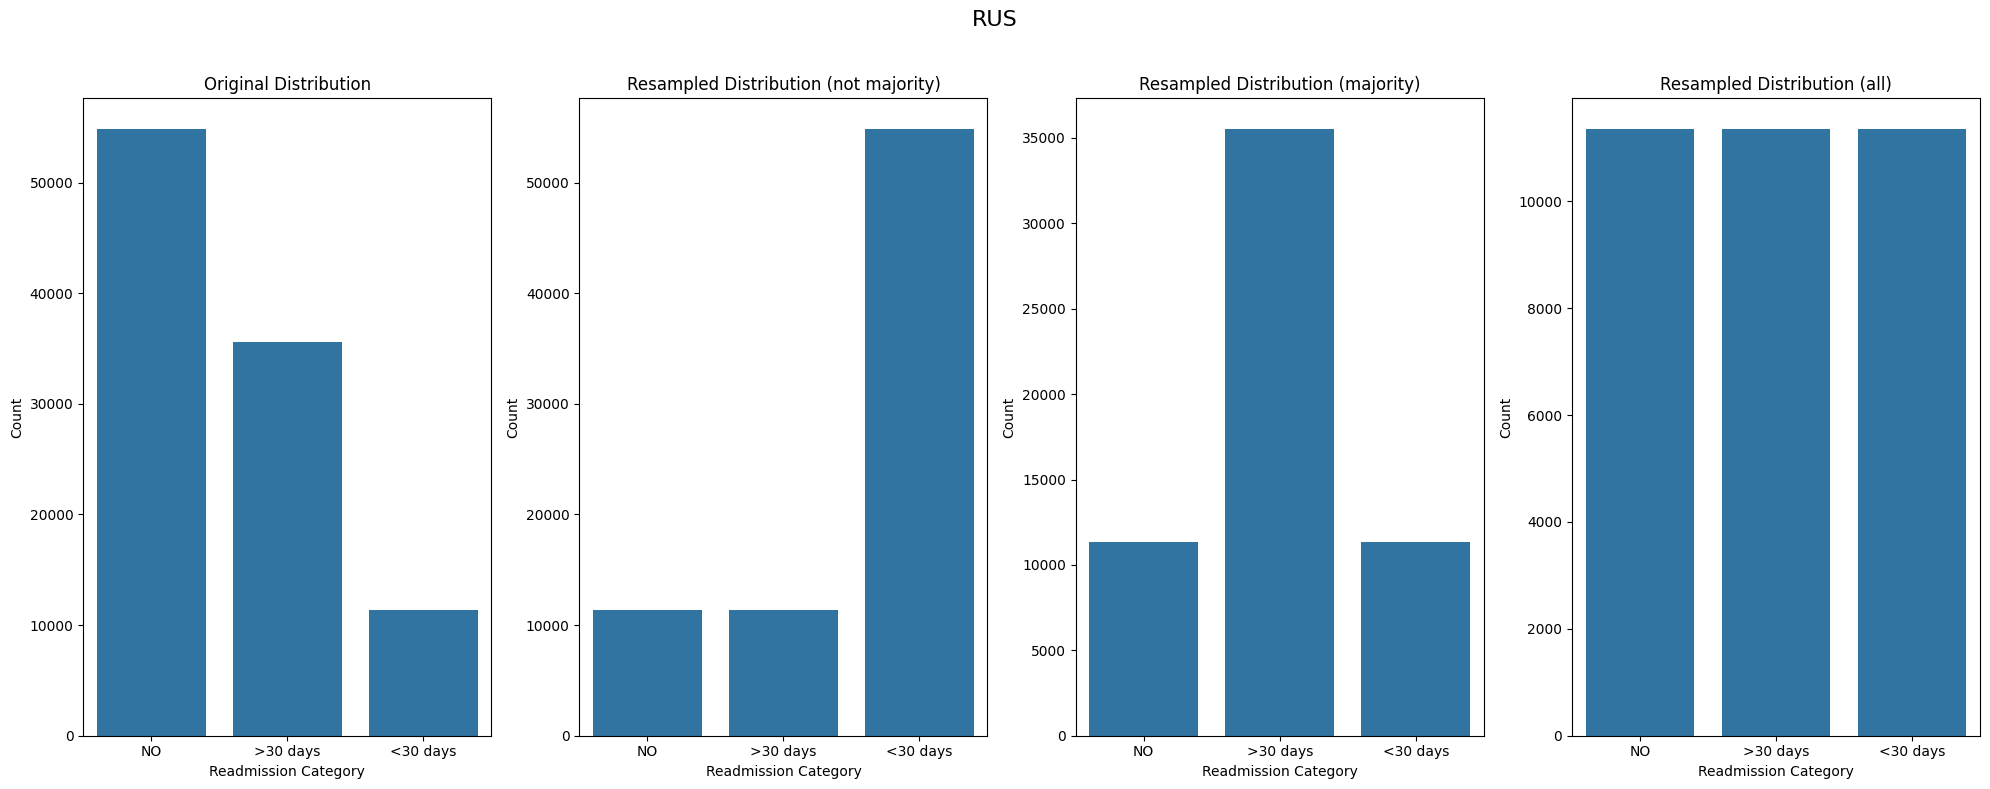

In [26]:
plot_class_distribution_4(y, y_rus, y_rus_maj, y_rus_all, "RUS")

In [31]:
# Random Over-sampling

ros = RandomOverSampler(sampling_strategy='not majority', random_state=1)
X_ros, y_ros = ros.fit_resample(X, y)
print("Original distribution:", Counter(y))
print("Over-sampling distribution:", Counter(y_ros))
# plot_class_distribution(y, y_ros, "Random Over-sampling (not majority)")

Original distribution: Counter({'NO': 54864, '>30': 35545, '<30': 11357})
Over-sampling distribution: Counter({'NO': 54864, '>30': 54864, '<30': 54864})


In [32]:
# SMOTE
smote = SMOTE(sampling_strategy='not majority', random_state=1)
X_sm, y_sm = smote.fit_resample(X, y)
print("Original distribution:", Counter(y))
print("SMOTE distribution:", Counter(y_sm))

Original distribution: Counter({'NO': 54864, '>30': 35545, '<30': 11357})
SMOTE distribution: Counter({'NO': 54864, '>30': 54864, '<30': 54864})


In [33]:
# ADASYN
adasyn = ADASYN(sampling_strategy='not majority', random_state=1)
X_asyn, y_asyn = adasyn.fit_resample(X, y)
print("Original distribution:", Counter(y))
print("ADASYN distribution:", Counter(y_asyn))

Original distribution: Counter({'NO': 54864, '>30': 35545, '<30': 11357})
ADASYN distribution: Counter({'>30': 60689, 'NO': 54864, '<30': 54431})


In [34]:
adasyn = ADASYN(sampling_strategy='auto', random_state=1)
X_asyn, y_asyn = adasyn.fit_resample(X, y)
print("Original distribution:", Counter(y))
print("ADASYN distribution:", Counter(y_asyn))

Original distribution: Counter({'NO': 54864, '>30': 35545, '<30': 11357})
ADASYN distribution: Counter({'>30': 60689, 'NO': 54864, '<30': 54431})
